# RS-CL & LIBERO

In [11]:
from pathlib import Path

from libero.libero import get_libero_path
from libero.libero.utils.download_utils import libero_dataset_download

datasets_root = Path(get_libero_path("datasets"))
spatial_dir = datasets_root / "libero_spatial"
if spatial_dir.is_dir() and any(spatial_dir.iterdir()):
    print(f"Skipping download; data already at {spatial_dir}")
else:
    libero_dataset_download(
        datasets="libero_spatial",
        check_overwrite=False,
        use_huggingface=True,
    )

Skipping download; data already at /Users/simonbruno/vla-rscl/data/libero/datasets/libero_spatial


In [12]:
from libero.libero import get_libero_path
from libero.libero.benchmark import get_benchmark

Benchmark = get_benchmark("libero_spatial")
benchmark = Benchmark()

print(f"Tasks: {benchmark.get_num_tasks()}")
for i, name in enumerate(benchmark.get_task_names()):
    print(f"  [{i}] {name}")

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Tasks: 10
  [0] pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate
  [1] pick_up_the_black_bowl_next_to_the_ramekin_and_place_it_on_the_plate
  [2] pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate
  [3] pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate
  [4] pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate
  [5] pick_up_the_black_bowl_on_the_ramekin_and_place_it_on_the_plate
  [6] pick_up_the_black_bowl_next_to_the_cookie_box_and_place_it_on_the_plate
  [7] pick_up_the_black_bowl_on_the_stove_and_place_it_on_the_plate
  [8] pick_up_the_black_bowl_next_to_the_plate_and_place_it_on_the_plate
  [9] pick_up_the_black_bowl_on_the_wooden_cabinet_and_place_it_on_the_plate


In [13]:
import h5py
import os

datasets_dir = get_libero_path("datasets")
demo_path = os.path.join(datasets_dir, benchmark.get_task_demonstration(0))
print(f"Demo file: {demo_path}")

f = h5py.File(demo_path, "r")
print(f"\nTop-level keys: {list(f.keys())}")

Demo file: /Users/simonbruno/vla-rscl/data/libero/datasets/libero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_demo.hdf5

Top-level keys: ['data']


In [14]:
# inspect structure of the first demo (episode)
data = f["data"]
demo_keys = sorted(data.keys())
print(f"Number of demos: {len(demo_keys)}")
print(f"Demo attributes: {dict(data.attrs)}")

demo = data[demo_keys[0]]
print(f"\n--- {demo_keys[0]} ---")
print(f"Attributes: {dict(demo.attrs)}")

def print_tree(group, prefix=""):
    for key in group:
        item = group[key]
        if isinstance(item, h5py.Dataset):
            print(f"{prefix}{key}: {item.shape} {item.dtype}")
        else:
            print(f"{prefix}{key}/")
            print_tree(item, prefix + "  ")

print_tree(demo)

Number of demos: 50
Demo attributes: {'bddl_file_name': 'libero/libero/bddl_files/libero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl', 'env_args': '{"type": 1, "env_name": "Libero_Tabletop_Manipulation", "problem_name": "libero_tabletop_manipulation", "bddl_file": "chiliocosm/bddl_files/libero_spatial/pick_the_akita_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate.bddl", "env_kwargs": {"robots": ["Panda"], "controller_configs": {"type": "OSC_POSE", "input_max": 1, "input_min": -1, "output_max": [0.05, 0.05, 0.05, 0.5, 0.5, 0.5], "output_min": [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5], "kp": 150, "damping_ratio": 1, "impedance_mode": "fixed", "kp_limits": [0, 300], "damping_ratio_limits": [0, 10], "position_limits": null, "orientation_limits": null, "uncouple_pos_ori": true, "control_delta": true, "interpolation": null, "ramp_ratio": 0.2}, "bddl_file_name": "chiliocosm/bddl_files/libero_spatial/pick_the_akita_black_

In [15]:
import numpy as np

# Action space
actions = demo["actions"][:]
print(f"Actions: {actions.shape} {actions.dtype}")
print(f"  min: {actions.min(axis=0)}")
print(f"  max: {actions.max(axis=0)}")
print(f"  mean: {actions.mean(axis=0)}")

Actions: (98, 7) float64
  min: [-0.9375     -0.20357143 -0.9375     -0.075      -0.11678571 -0.19285714
 -1.        ]
  max: [0.87589286 0.63214286 0.84107143 0.09107143 0.15321429 0.12535714
 1.        ]
  mean: [ 0.20769862  0.11728316 -0.13286261  0.00611152 -0.00305029 -0.03629738
  0.        ]


In [16]:
obs = demo["obs"]
print("observation keys:")
for k in sorted(obs.keys()):
    item = obs[k]
    print(f"  {k}: {item.shape} {item.dtype}")

# stats for every dataset: 2D (time × features) per-column min/max, otherwise one global min/max (e.g. RGB)

# agentview = third person camera image (rgb, main exterior view)
# ee_ori = end-effector orientation (robot's hand)
# ee_pos = end-effector position in world frame (robot's hand)
# ee_states = end-effector state (position and orientation) concatenated
# eye_in_hand = wrist camera image (rgb, robot's wrist)
# gripper_states = gripper finger positions (how open/closed)
# joint_states = absolute joint angles 

print("\nper-key stats:")
for key in sorted(obs.keys()):
    item = obs[key]
    if not isinstance(item, h5py.Dataset):
        continue
    arr = item[:]
    print(f"\n{key}: {arr.shape} {arr.dtype}")
    if arr.ndim == 2:
        print(f"  min:  {arr.min(axis=0)}")
        print(f"  max:  {arr.max(axis=0)}")
    else:
        print(f"  min:  {arr.min()}  max:  {arr.max()}  (over all elements)")

observation keys:
  agentview_rgb: (98, 128, 128, 3) uint8
  ee_ori: (98, 3) float64
  ee_pos: (98, 3) float64
  ee_states: (98, 6) float64
  eye_in_hand_rgb: (98, 128, 128, 3) uint8
  gripper_states: (98, 2) float64
  joint_states: (98, 7) float64

per-key stats:

agentview_rgb: (98, 128, 128, 3) uint8
  min:  0  max:  255  (over all elements)

ee_ori: (98, 3) float64
  min:  [ 3.09782852 -0.79503123 -0.20627669]
  max:  [3.14507411e+00 9.29487348e-04 5.99352042e-02]

ee_pos: (98, 3) float64
  min:  [-0.21290562 -0.00209874  0.92867525]
  max:  [0.09772929 0.1777582  1.183028  ]

ee_states: (98, 6) float64
  min:  [-2.12905620e-01 -2.09874393e-03  9.28675249e-01  3.09782852e+00
 -7.95031232e-01 -2.06276686e-01]
  max:  [9.77292899e-02 1.77758200e-01 1.18302800e+00 3.14507411e+00
 9.29487348e-04 5.99352042e-02]

eye_in_hand_rgb: (98, 128, 128, 3) uint8
  min:  0  max:  253  (over all elements)

gripper_states: (98, 2) float64
  min:  [ 0.00189937 -0.03965339]
  max:  [ 0.03974004 -0.00

image obs keys: ['agentview_rgb', 'eye_in_hand_rgb']


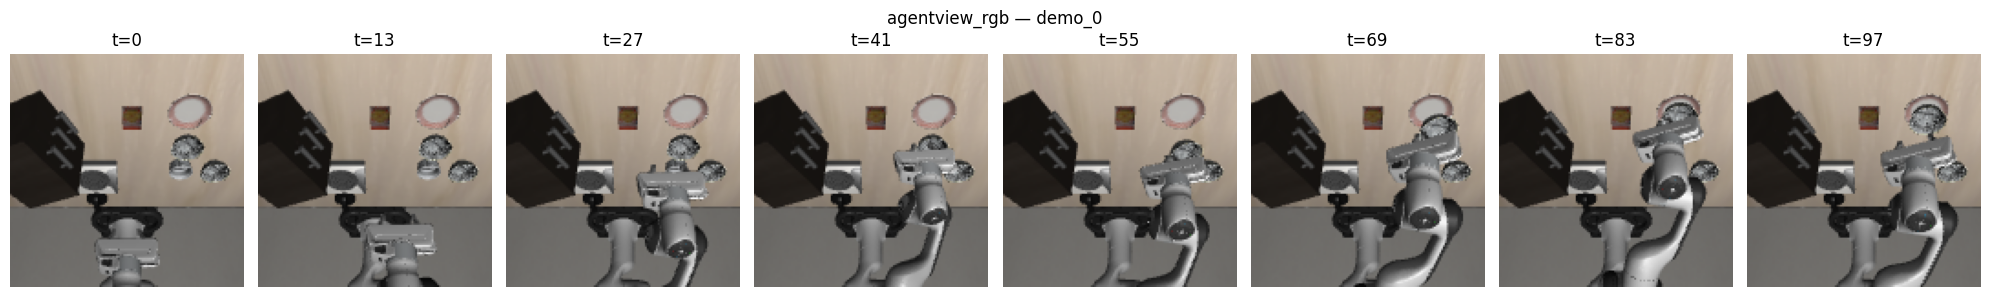

In [17]:
import matplotlib.pyplot as plt

# visualize first demo
img_keys = [k for k in obs if "image" in k or "img" in k or "agentview" in k or "eye" in k]
print(f"image obs keys: {img_keys}")

if img_keys:
    key = img_keys[0]
    imgs = obs[key][:]
    idxs = np.linspace(0, len(imgs) - 1, 8, dtype=int)

    fig, axes = plt.subplots(1, len(idxs), figsize=(20, 3))
    for ax, i in zip(axes, idxs):
        ax.imshow(imgs[i])
        ax.set_title(f"t={i}")
        ax.axis("off")
    plt.suptitle(f"{key} — {demo_keys[0]}")
    plt.tight_layout()
    plt.show()

In [18]:
f.close()